In [ ]:
!pip install tensorflow
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 746.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Mounted at /content/drive


In [5]:
# ==========================================
# 2. LOAD DATA (The Fast Way)
# ==========================================
# We use the parent directory. Keras will automatically find "AI" and "Real" subfolders
# and assign labels (0 and 1) automatically.

dataset_path = "/content/drive/MyDrive/Dataset"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print(f"Loading images from {dataset_path}...")

# Load everything as one main dataset first
main_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=None, # We will split manually for better control
    label_mode='int',      # 0 or 1
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Print class names so we know which is 0 and which is 1
class_names = main_dataset.class_names
print(f"Classes found: {class_names}")
# Usually: class_names[0] is AI, class_names[1] is Real (Alphabetical order)

Loading images from /content/drive/MyDrive/Dataset...
Found 971 files belonging to 2 classes.
Classes found: ['AiArtData', 'RealArt']


In [6]:
# ==========================================
# 3. SPLIT DATA (Train / Val / Test)
# ==========================================
# Instead of converting to numpy lists (which is slow), we keep it as a Tensor Pipeline

total_batches = tf.data.experimental.cardinality(main_dataset).numpy()
train_size = int(0.7 * total_batches)
val_size = int(0.15 * total_batches)
test_size = int(0.15 * total_batches)

train_ds = main_dataset.take(train_size)
remaining = main_dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

In [7]:
# ==========================================
# 4. OPTIMIZE PERFORMANCE (Speed Fix)
# ==========================================
# AUTOTUNE allows the CPU to load the next batch while the GPU trains the current one.
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_data(image, label):
    # Xception requires specific preprocessing (-1 to 1 scaling)
    return keras.applications.xception.preprocess_input(image), label

train_ds = train_ds.map(preprocess_data).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(preprocess_data).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(preprocess_data).cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
# ==========================================
# 5. DATA AUGMENTATION
# ==========================================
# Helps improve accuracy by creating slight variations of images
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [9]:
# ==========================================
# 6. BUILD MODEL (Xception)
# ==========================================
# Xception is chosen because it is widely considered the best for Deepfake/AI detection

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze initially for speed

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Reduce overfitting
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# Callbacks
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ==========================================
# 7. TRAINING
# ==========================================
print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # You can increase this, but EarlyStopping will stop it if it gets good
    callbacks=[checkpoint, reduce_lr, early_stop]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Starting training...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6008 - loss: 0.7024
Epoch 1: val_accuracy improved from -inf to 0.71094, saving model to best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.6017 - loss: 0.7009 - val_accuracy: 0.7109 - val_loss: 0.5185 - learning_rate: 0.0010
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7467 - loss: 0.5174
Epoch 2: val_accuracy improved from 0.71094 to 0.71875, saving model to best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.7477 - loss: 0.5160 - val_accuracy: 0.7188 - val_loss: 0.4570 - learning_rate: 0.0010
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8195 - loss: 0.4099
Epoch 3: val_accuracy improved from 0.71875 to 0.78125, saving model to best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8189 - loss: 0.4107 - val_accuracy: 0.7812 - val_loss: 0.4323 - learning_rate: 0.0010
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step 

Unfreezing model for fine-tuning...
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8191 - loss: 0.4227 
Epoch 1: val_accuracy did not improve from 0.82812
21/21 ━━━━━━━━━━━━━━━━━━━━ 273s 12s/step - accuracy: 0.8188 - loss: 0.4229 - val_accuracy: 0.8281 - val_loss: 0.3857 - learning_rate: 1.0000e-05
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8366 - loss: 0.3781 
Epoch 2: val_accuracy did not improve from 0.82812
21/21 ━━━━━━━━━━━━━━━━━━━━ 254s 12s/step - accuracy: 0.8368 - loss: 0.3776 - val_accuracy: 0.8125 - val_loss: 0.3949 - learning_rate: 1.0000e-05
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8741 - loss: 0.3421 
Epoch 3: val_accuracy did not improve from 0.82812
21/21 ━━━━━━━━━━━━━━━━━━━━ 254s 12s/step - accuracy: 0.8744 - loss: 0.3413 - val_accuracy: 0.8047 - val_loss: 0.3947 - learning_rate: 1.0000e-05
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8791 - loss: 0.3010 
Epoch 4: val_accuracy did not improv

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


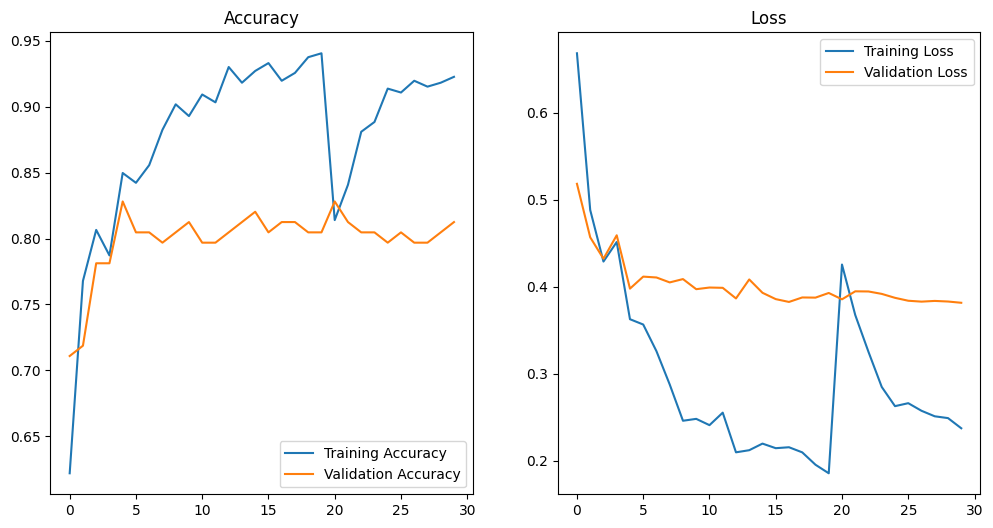

Generating predictions for test set...
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Accuracy: 0.8187134502923976
Precision: 0.8142857142857143
Recall: 0.76
F1 Score: 0.7862068965517242
Confusion Matrix:
 [[83 13]
 [18 57]]


In [ ]:
# ==========================================
# 8. FINE TUNING (The Accuracy Boost)
# ==========================================
# Unfreeze the base model to learn specific AI artifacts
print("Unfreezing model for fine-tuning...")
base_model.trainable = True

# Recompile with very low learning rate
model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

# ==========================================
# 9. EVALUATION & PLOTTING
# ==========================================
# Reload best model
model.load_weights('best_model.keras')

# 1. Plot Training History
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 2. Generate Predictions for Metrics
print("Generating predictions for test set...")
# We need to extract labels and images from the dataset to compare
test_images = []
test_labels = []

# Unbatch the test dataset to get raw arrays
for img, label in test_ds:
    test_images.append(img.numpy())
    test_labels.append(label.numpy())

# Flatten lists
test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

# Predict
y_pred_probs = model.predict(test_images)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Metrics
print("Accuracy:", accuracy_score(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred))
print("Recall:", recall_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred))
print("Confusion Matrix:\n", confusion_matrix(test_labels, y_pred))

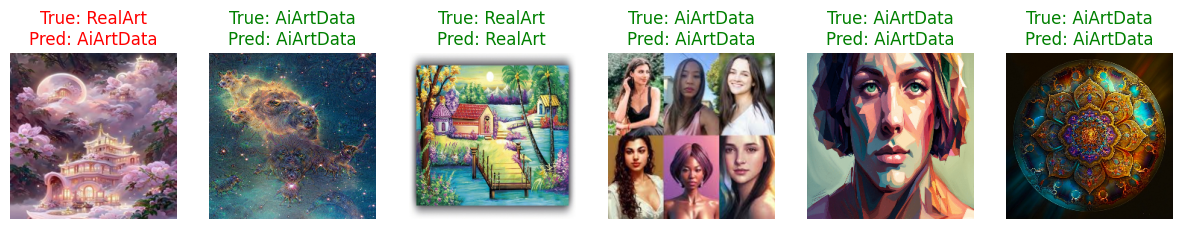

In [11]:
# ==========================================
# 10. VISUALIZATION (Fixed for new pipeline)
# ==========================================
def display_classified_images(images, true_labels, predicted_labels, class_names, max_images=6):
    # Convert inputs to standard numpy
    true_labels = np.array(true_labels).flatten()
    predicted_labels = np.array(predicted_labels).flatten()

    # Indices for visualization
    indices = np.arange(len(true_labels))
    np.random.shuffle(indices)

    plt.figure(figsize=(15, 5))

    count = 0
    for i in indices:
        if count >= max_images:
            break

        img = images[i]
        # Reverse preprocessing for display (Xception scales to -1..1, we need 0..1)
        img = (img + 1) / 2.0
        img = np.clip(img, 0, 1)

        ax = plt.subplot(1, max_images, count + 1)
        plt.imshow(img)

        true_name = class_names[int(true_labels[i])]
        pred_name = class_names[int(predicted_labels[i])]

        color = 'green' if true_labels[i] == predicted_labels[i] else 'red'

        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color)
        plt.axis("off")
        count += 1
    plt.show()

# Display results
display_classified_images(test_images, test_labels, y_pred, class_names)